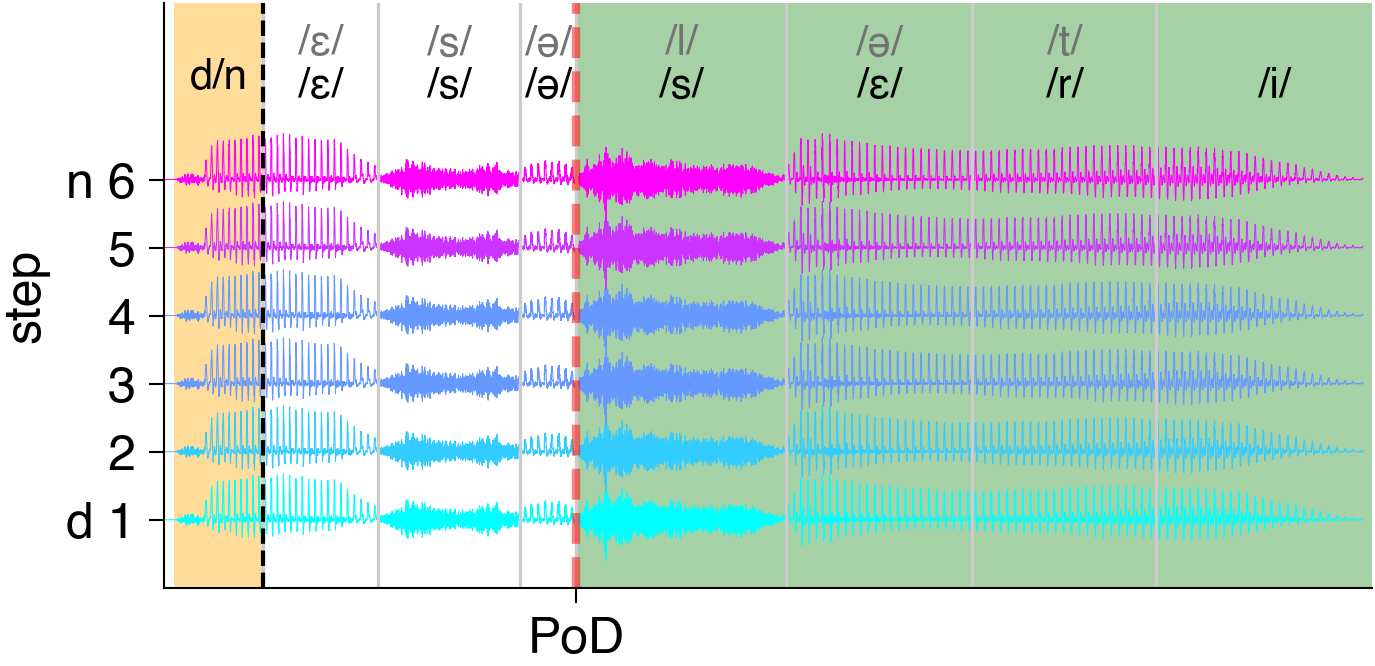

In [7]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.image as mpimg
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, TextArea, OffsetImage
from scipy.io import wavfile
import textgrid

matplotlib.rcParams.update({
    "figure.dpi": 300,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.25,
    "ytick.minor.width": 0.25,
    "lines.linewidth": 1.0,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial"],
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
})

# ── Parameters ──────────────────────────────────────────────────────────────
pair_to_use    = 'dn'
word_to_use    = 'necessary'
acoustic_step  = '002'
word_not_to_use = 'desolate'
phon_pod       = 5          # 1-based index (kept as-is; adjusted below where needed)
fs             = 44100
n_steps        = 6
wav_spacing    = 2
rootdir        = os.path.expanduser('textgrids')
post_pod_compress = 1       # horizontal compression factor for post-PoD region

font_name  = 'Helvetica'
font_size  = 12
phone_font_size = 10

# formerly (with compression=2): 5.1, 3
figsize = (6.71, 3)

# ── Colormap (cool, with step 4 == step 3) ──────────────────────────────────
cool_cmap = plt.get_cmap('cool', n_steps)
cm = np.array([cool_cmap(i) for i in range(n_steps)])
cm[3] = cm[2]   # steps 3 & 4 same (0-based: indices 2 & 3)

# ── Helper: load TextGrid intervals via the `textgrid` library ───────────────
def load_intervals(path):
    """Return list of (xmin, xmax, text) tuples for the first interval tier."""
    tg = textgrid.TextGrid.fromFile(path)
    # Find the first IntervalTier
    for tier in tg.tiers:
        if isinstance(tier, textgrid.IntervalTier):
            return [(iv.minTime, iv.maxTime, iv.mark) for iv in tier]
    raise ValueError(f"No IntervalTier found in {path}")

# ── Load stimuli & phoneme data (word_to_use) ────────────────────────────────
file_list = sorted([
    f for f in os.listdir(rootdir)
    if word_to_use in f and pair_to_use in f and f.endswith('.wav')
])

stims         = []
phoneme_start = []
phoneme_end   = []
phoneme_id    = []

for fname in file_list:
    # Load wav, trim half-second tail
    sr, data = wavfile.read(os.path.join(rootdir, fname))
    if data.ndim > 1:
        data = data[:, 0]
    data = data[:len(data) - sr // 2].astype(float)
    # Normalise to [-1, 1] if integer dtype
    if np.issubdtype(wavfile.read(os.path.join(rootdir, fname))[1].dtype, np.integer):
        data = data / np.iinfo(wavfile.read(os.path.join(rootdir, fname))[1].dtype).max
    stims.append(data)

    tg_path = os.path.join(rootdir, os.path.splitext(fname)[0] + '.TextGrid')
    intervals = load_intervals(tg_path)
    # Skip first and last interval (matches MATLAB j = 2:length(f)-1)
    middle = intervals[1:-1]
    phoneme_start.append([iv[0] for iv in middle])
    phoneme_end.append(  [iv[1] for iv in middle])
    phoneme_id.append(   [iv[2] for iv in middle])

# ── Load alt phoneme data (word_not_to_use) ──────────────────────────────────
alt_file_list = sorted([
    f for f in os.listdir(rootdir)
    if word_not_to_use in f and pair_to_use in f and f.endswith('.wav')
])

tg_path_alt = os.path.join(
    rootdir, os.path.splitext(alt_file_list[0])[0] + '.TextGrid'
)
alt_intervals  = load_intervals(tg_path_alt)[1:-1]
alt_phon_start = [iv[0] for iv in alt_intervals]
alt_phon_end   = [iv[1] for iv in alt_intervals]
alt_phon_id    = [iv[2] for iv in alt_intervals]

# ── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=figsize, facecolor='white')
ax = fig.add_axes([0.12, 0.15, 0.60, 0.65])   # main waveform axes

max_len = max(len(s) for s in stims)

# 0-based phoneme_of_divergence index
pod = phon_pod - 1   # e.g. 5 → 4

j = 0   # always plot first stimulus (MATLAB j=1 throughout the loop)

# ── x-axis compression helper ────────────────────────────────────────────────
ps = phoneme_start[j]
pe = phoneme_end[j]
pi = phoneme_id[j]

pod_sample = ps[pod] * fs   # PoD boundary in samples

def xmap(x):
    """Map sample positions to display coords, compressing post-PoD."""
    x = np.asarray(x, dtype=float)
    return np.where(x <= pod_sample,
                    x,
                    pod_sample + (x - pod_sample) / post_pod_compress)

for i in range(n_steps):
    y_offset = (i + 1) * wav_spacing
    x_display = xmap(np.arange(len(stims[j])))
    ax.plot(x_display, stims[j] * 1.5 + y_offset, color=cm[i], linewidth=0.25)

ax.set_xlim(0, xmap(max_len))

# ── Phoneme labels & overlays (drawn after all waveforms) ────────────────────
y_min, y_max = ax.get_ylim()
label_y1 = y_max + y_max * 0.03
label_y2 = y_max + y_max * 0.12

for k in range(1, len(ps)):          # skip first phoneme for grid lines
    mid_x = xmap(np.mean([pe[k] * fs, ps[k] * fs]))

    # Primary phoneme label (black)
    ax.text(mid_x, label_y1, f'/{pi[k]}/',
            ha='center', fontfamily=font_name, fontsize=phone_font_size)

    # Grey divider line
    ax.axvline(xmap(ps[k] * fs), color=[0.8, 0.8, 0.8], linewidth=0.8)

    # Alt phoneme label (grey, same position logic for all k)
    if k < len(alt_phon_start):  # check index in bounds for alt phoneme data
        ax.text(mid_x, label_y2, f'/{alt_phon_id[k]}/',
                ha='center', fontfamily=font_name, fontsize=phone_font_size,
                color=[0.45, 0.45, 0.45])

# d/n label over first phoneme
ax.text(xmap(np.mean([pe[0] * fs, ps[0] * fs])),
        y_max + y_max * 0.05,
        f'{pair_to_use[0]}/{pair_to_use[1]}',
        ha='center', fontfamily=font_name, fontsize=phone_font_size)

# Extend y-axis to make room for labels
ax.set_ylim(0, y_max + y_max * 0.23)
y_min2, y_max2 = ax.get_ylim()

# Red dashed line at PoD
ax.axvline(xmap(ps[pod] * fs), color=(1.0, 0.0, 0.0, 0.5),
           linestyle='--', linewidth=2)

# Black dashed line at end of first phoneme
ax.axvline(xmap(pe[0] * fs), color='k', linestyle='--')

# # Blue dashed line at end of last phoneme of previous step
# # (MATLAB: phonemeEnd{j-1}{end} – since j=1 always, this is stims[0] last phoneme)
# ax.axvline(xmap(pe[-1] * fs), color=(0.0, 0.0, 1.0, 0.5),
#            linestyle='--', linewidth=2)

# Orange rectangle: first phoneme region
rect1 = patches.Rectangle(
    (xmap(ps[0] * fs), y_min2),
    (xmap(pe[0] * fs) - xmap(ps[0] * fs)), (y_max2 - y_min2),
    facecolor=(1, 0.6571, 0), alpha=0.4, edgecolor='none'
)
ax.add_patch(rect1)

# Green rectangle: PoD → end
rect2 = patches.Rectangle(
    (xmap(ps[pod] * fs), y_min2),
    (xmap(pe[-1] * fs) - xmap(ps[pod] * fs)), (y_max2 - y_min2),
    facecolor=(0.1333, 0.5451, 0.1333), alpha=0.4, edgecolor='none'
)
ax.add_patch(rect2)

# ── Y-axis ticks ─────────────────────────────────────────────────────────────
ytick_vals   = [i * wav_spacing for i in range(1, n_steps + 1)]  # 2, 4, 6, 8, 10, 12
ytick_labels = []
for i in range(1, n_steps + 1):
    if i == 1:
        ytick_labels.append(f'{pair_to_use[0]} {i}')
    elif i == n_steps:
        ytick_labels.append(f'{pair_to_use[1]} {i}')
    else:
        ytick_labels.append(str(i))

ax.set_yticks(ytick_vals)
ax.set_yticklabels(ytick_labels, fontfamily=font_name, fontsize=font_size)
ax.set_ylabel('step', fontfamily=font_name, fontsize=font_size)

ax.set_xticks([xmap(ps[pod] * fs)])
ax.set_xticklabels(['PoD'], fontfamily=font_name, fontsize=font_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# # ── Legend-style box with text + hand image ──────────────────────────────────
# legend_alpha = 0.9
# tp = dict(fontfamily=font_name, fontsize=font_size - 1, ha='center',
#           alpha=legend_alpha)
# text_items = [
#     TextArea('\u201cnecessary\u201d', textprops=tp),
#     TextArea('or',                    textprops=tp),
#     TextArea('\u201cdecessary\u201d', textprops=tp),
#     TextArea('?',                     textprops=tp),
# ]

# hand_path = os.path.join(rootdir, '..', 'hand.png')
# if os.path.exists(hand_path):
#     hand_img = mpimg.imread(hand_path)
#     # Ensure RGBA and bake in alpha
#     if hand_img.shape[2] == 3:
#         hand_img = np.dstack([hand_img, np.ones(hand_img.shape[:2])])
#     hand_img = hand_img.copy()
#     hand_img[:, :, 3] *= legend_alpha
#     img_box = OffsetImage(hand_img, zoom=0.08)
#     text_items.append(img_box)

# box = VPacker(children=text_items, align='center', pad=0, sep=3)
# anchored = AnchoredOffsetbox(
#     loc='lower right', child=box, pad=0.4,
#     bbox_to_anchor=(1, 0), bbox_transform=ax.transAxes,
#     frameon=True,
# )
# anchored.patch.set_boxstyle('round,pad=0.4')
# anchored.patch.set_facecolor('white')
# anchored.patch.set_edgecolor('0.6')
# anchored.patch.set_linewidth(0.8)
# anchored.patch.set_alpha(legend_alpha)
# ax.add_artist(anchored)

# ── Export ────────────────────────────────────────────────────────────────────
fig.savefig(os.path.expanduser('figures/task.pdf'),
            format='pdf', bbox_inches='tight')
plt.show()